<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Parametric_Amplification_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

### This notebook starts with some simple plots to visualize amplification typically performed by superconducting, quantum-limited parametric amplifiers. It then progresses to simulation plots for a slightly more realistic output.

The exploration of superconducting quantum devices demands precise numerical simulations to visualize wave propagation dynamics because the fundamental operational mechanism relies inherently upon the nondissipative nonlinearity originating from the Josephson junction (JJ). The macroscopic quantum behavior of this discrete superconducting weak link produces a purely dispersive response, which is governed by the standard Josephson relations for the supercurrent $I$ and the voltage $V$, explicitly given by $I = I_c \sin(\varphi)$ and $V = \frac{\Phi_0}{2\pi} \frac{d\varphi}{dt}$, where $I_c$ represents the critical current, $\Phi_0$ denotes the magnetic flux quantum, and $\varphi$ signifies the superconducting phase difference across the junction. Taking the temporal derivative of the supercurrent reveals a phase dependent dynamic inductance defined by $L_J(\varphi) = \frac{\Phi_0}{2\pi I_c \cos(\varphi)}$. Expanding this inductive term via a Taylor series generates the essential higher order electrical nonlinearities that mediate continuous energy exchange among interacting propagating modes or localized cavity resonances. Utilizing this physical mechanism, a Josephson Traveling Wave Parametric Amplifier (JTWPA) facilitates the spatial mixing of microwaves along a transmission line, transferring energy from a high power pump wave to a weaker signal wave while concurrently generating an idler wave. The continuous spatial evolution of these complex wave amplitudes is modeled through Coupled Mode Theory (CMT), employing Ordinary Differential Equations (ODEs) across the spatial propagation distance $z$. The primary variables include the complex slowly varying signal amplitude $A_s(z)$, the complex slowly varying idler amplitude $A_i(z)$, the parametric coupling strength $\kappa$, and the phase mismatch $\Delta k$. Conversely, a Josephson Parametric Amplifier (JPA) operates as a localized resonant cavity, which is mathematically represented in the time domain $t$ as a driven, damped harmonic oscillator featuring a modulated kinetic inductance. The governing parameters for the localized cavity include the resonant angular frequency $\omega_0$, the dissipative damping rate $\gamma$, and the fractional modulation depth $\lambda$.

The governing coupled mode equations for the spatial envelope evolution are formulated below.

$$ \frac{dA_s(z)}{dz} = i \kappa A_i^*(z) e^{-i \Delta k z} $$

$$ \frac{dA_i^*(z)}{dz} = -i \kappa A_s(z) e^{i \Delta k z} $$

The parametric amplification of the intracavity flux $\Phi(t)$ relies on the following classical Mathieu equation.

$$ \frac{d^2\Phi(t)}{dt^2} + \gamma \frac{d\Phi(t)}{dt} + \omega_0^2 (1 + \lambda \cos(2\omega_0 t)) \Phi(t) = 0 $$

In summary, the foundational nonlinearity of the Josephson junction dynamic inductance provides the essential wave mixing physical basis required to accurately parameterize both the spatial signal growth and the temporal resonant cavity modulation.

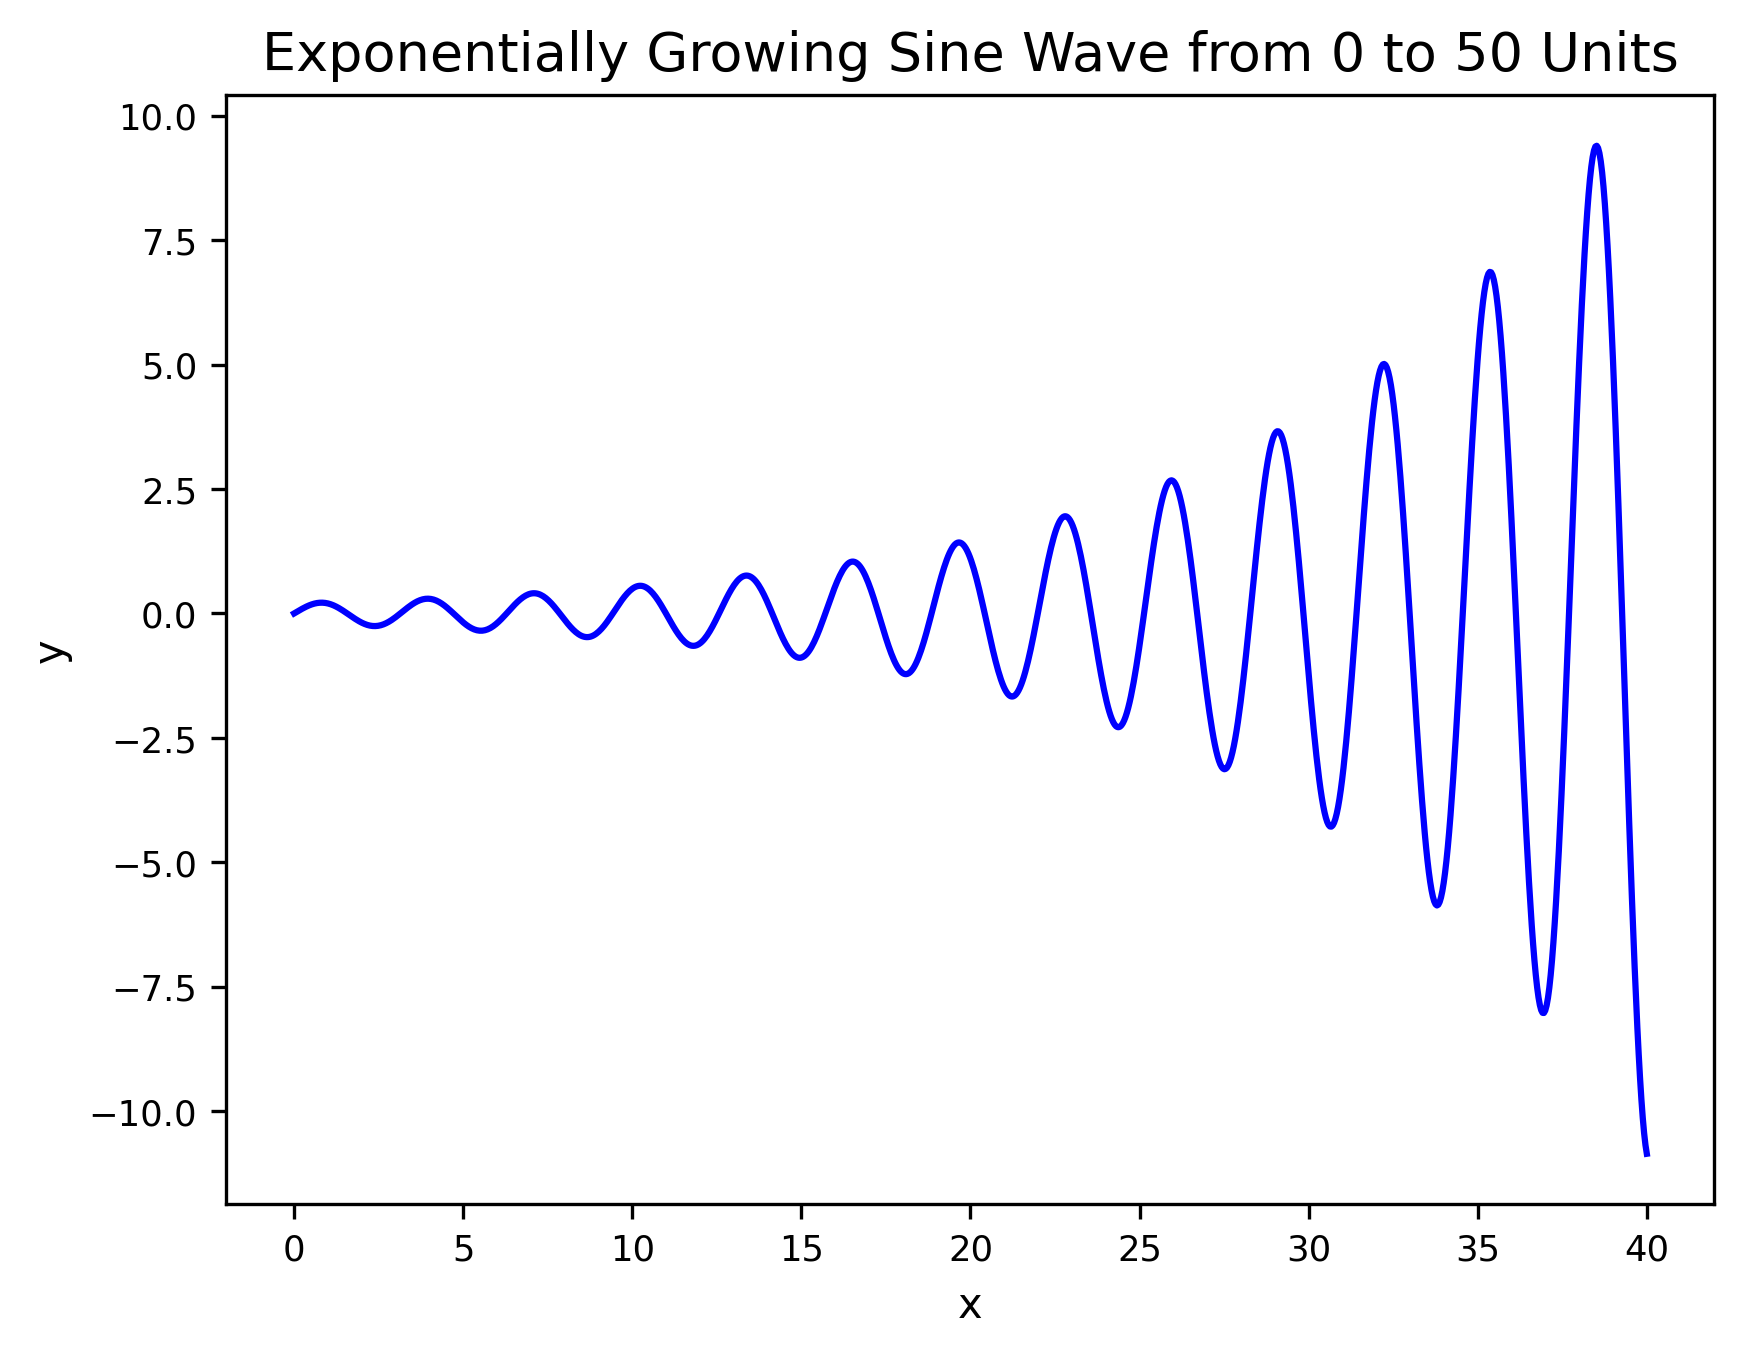

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Set high DPI via rcParams
plt.rcParams['figure.dpi'] = 300

# Generate data
x = np.linspace(0, 40, 1000)            # Range from 0 to 50
amplitude = 0.2 * np.exp(0.1 * x)       # Start at 0.2 and grow exponentially
y = amplitude * np.sin(2 * x)

# Create figure and plot
plt.figure()
plt.plot(x, y, color='blue', label='Exponentially Growing Sine (0.2 initial)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Exponentially Growing Sine Wave from 0 to 50 Units')

# Remove grid lines
plt.grid(False)

# Optional: show legend
# plt.legend()

# Display the plot
plt.show()


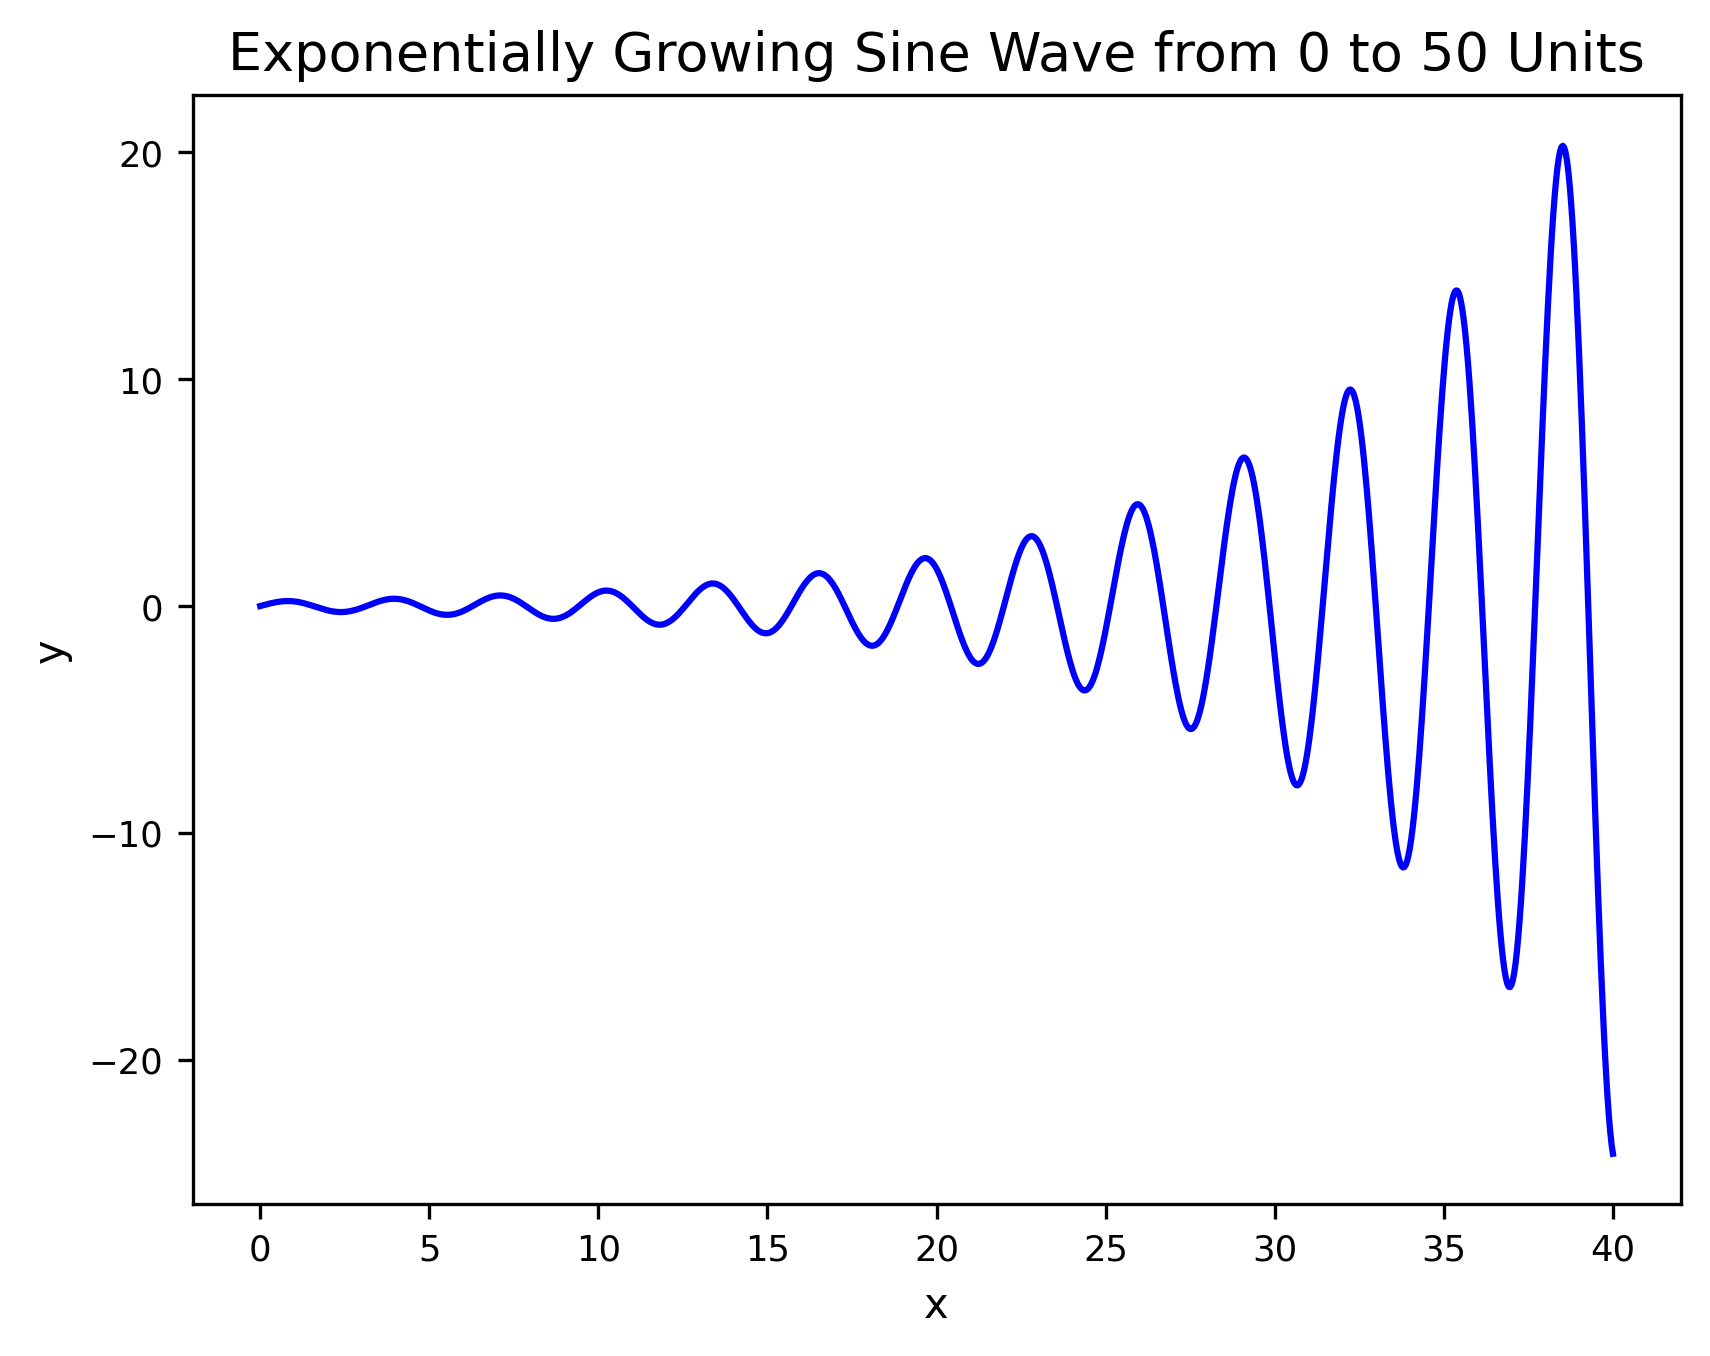

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Set high DPI via rcParams
plt.rcParams['figure.dpi'] = 300

# Generate data
x = np.linspace(0, 40, 1000)            # Range from 0 to 50
amplitude = 0.2 * np.exp(0.12 * x)       # Start at 0.2 and grow exponentially at a different rate
y = amplitude * np.sin(2 * x)

# Create figure and plot
plt.figure()
plt.plot(x, y, color='blue', label='Exponentially Growing Sine (0.2 initial)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Exponentially Growing Sine Wave from 0 to 50 Units')

# Remove grid lines
plt.grid(False)

# Optional: show legend
# plt.legend()

# Display the plot
plt.show()

PyTorch device: cuda:0
Real dtype: torch.float32
Complex dtype: torch.complex64
CUDA device name: Tesla T4
Allocated CUDA memory before simulations: 57.42 MiB


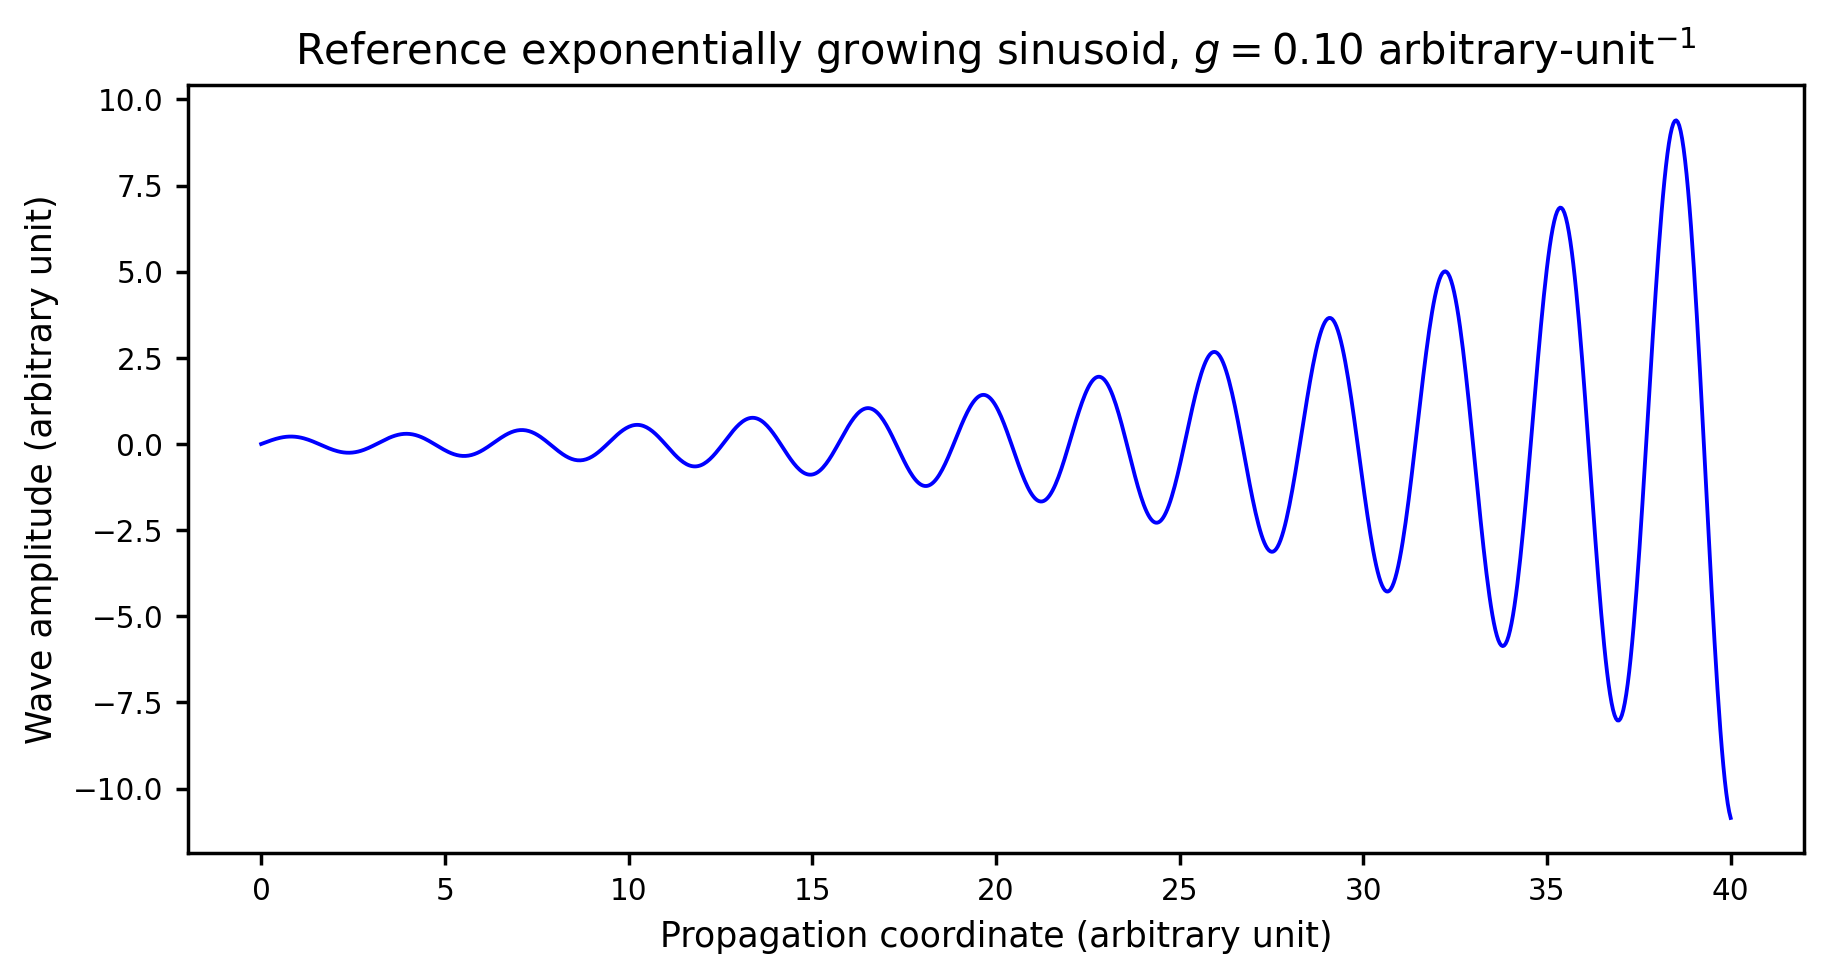

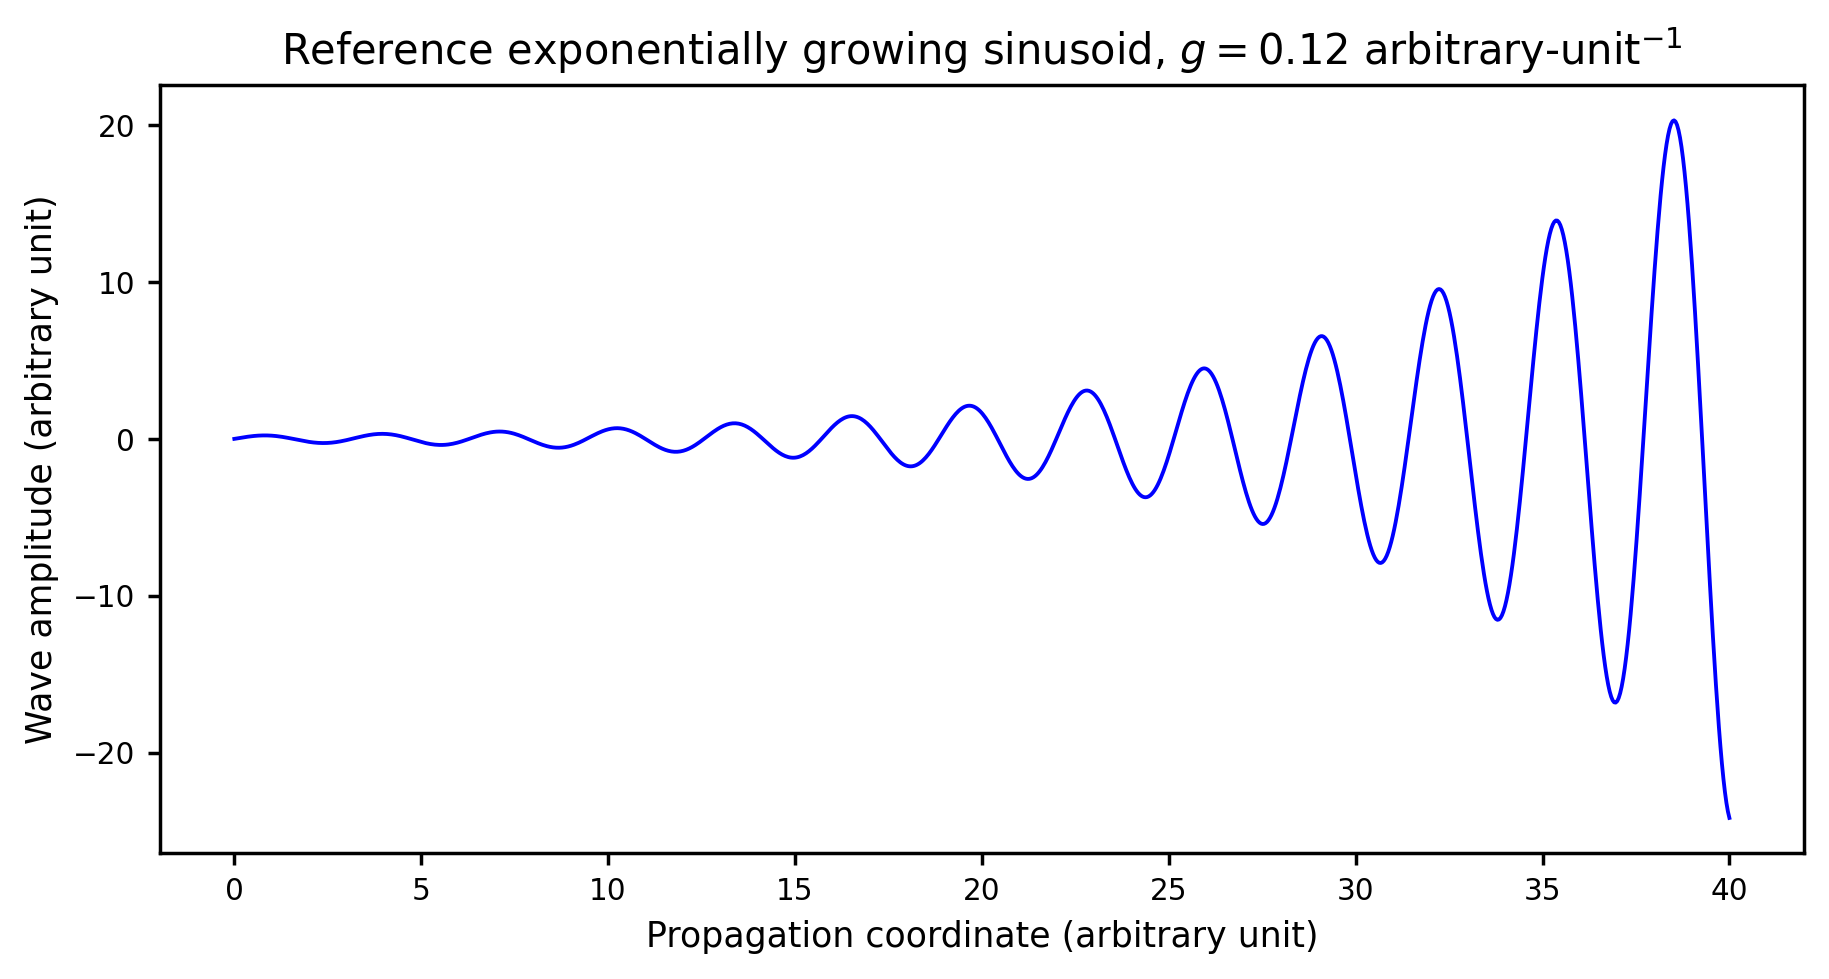

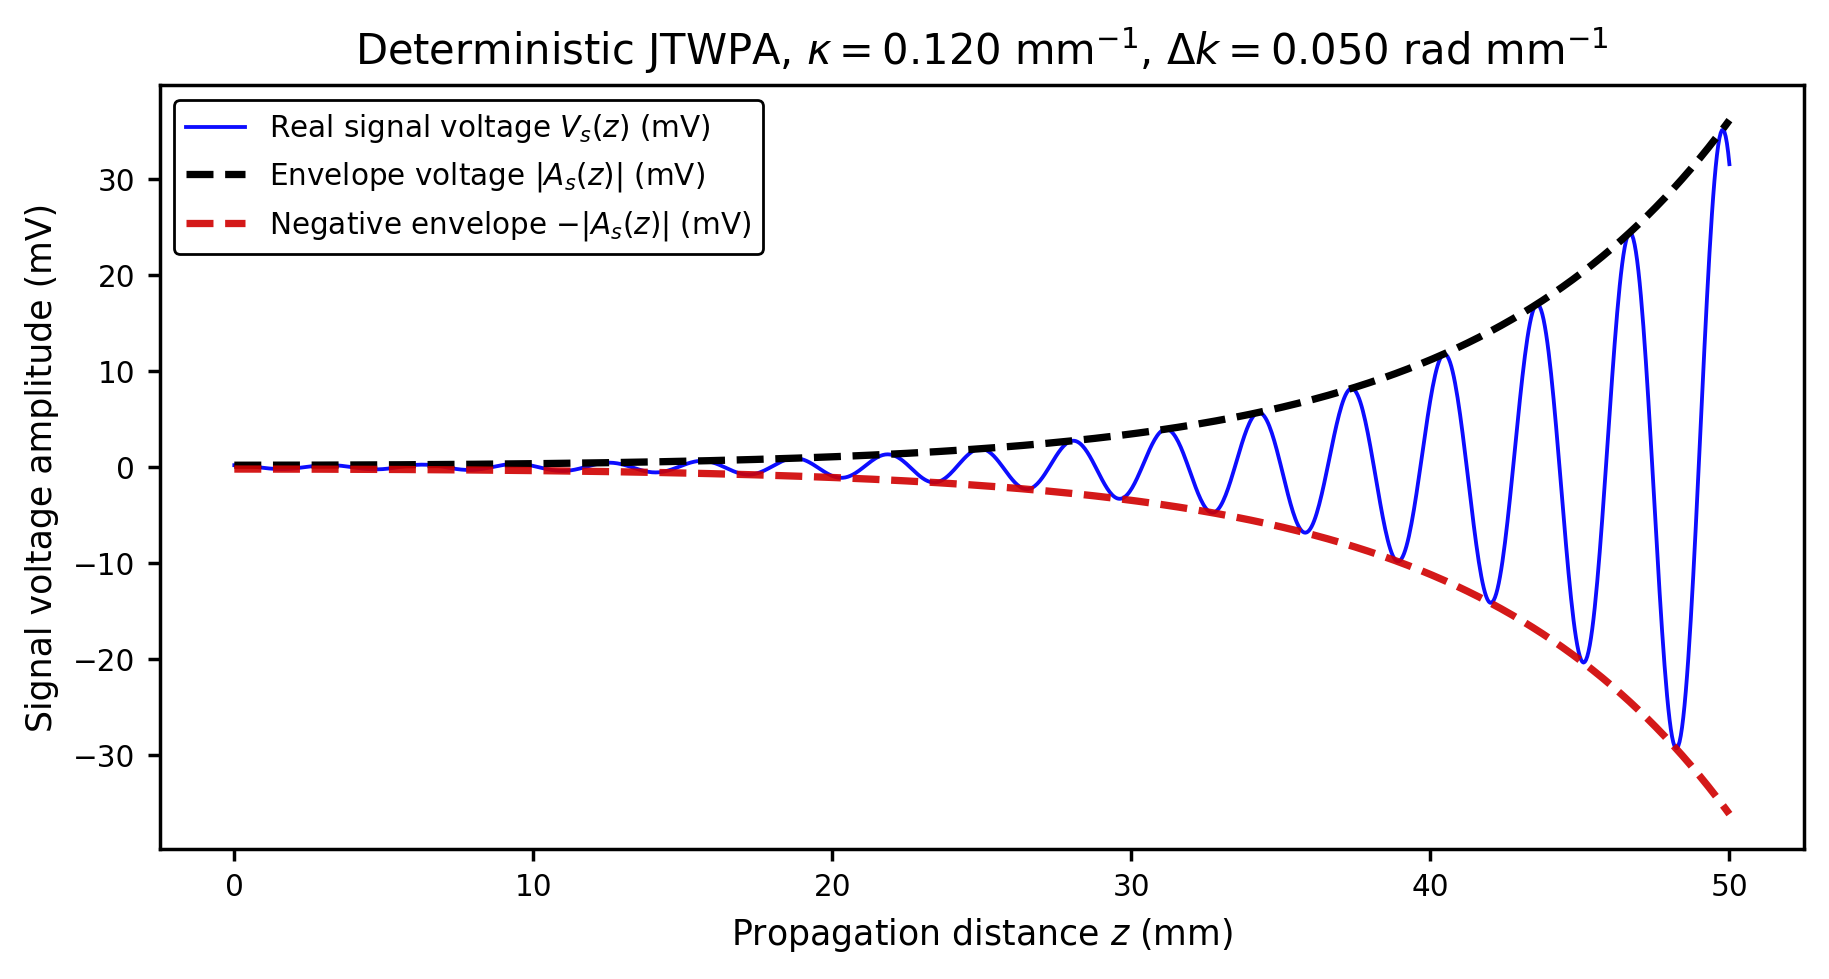

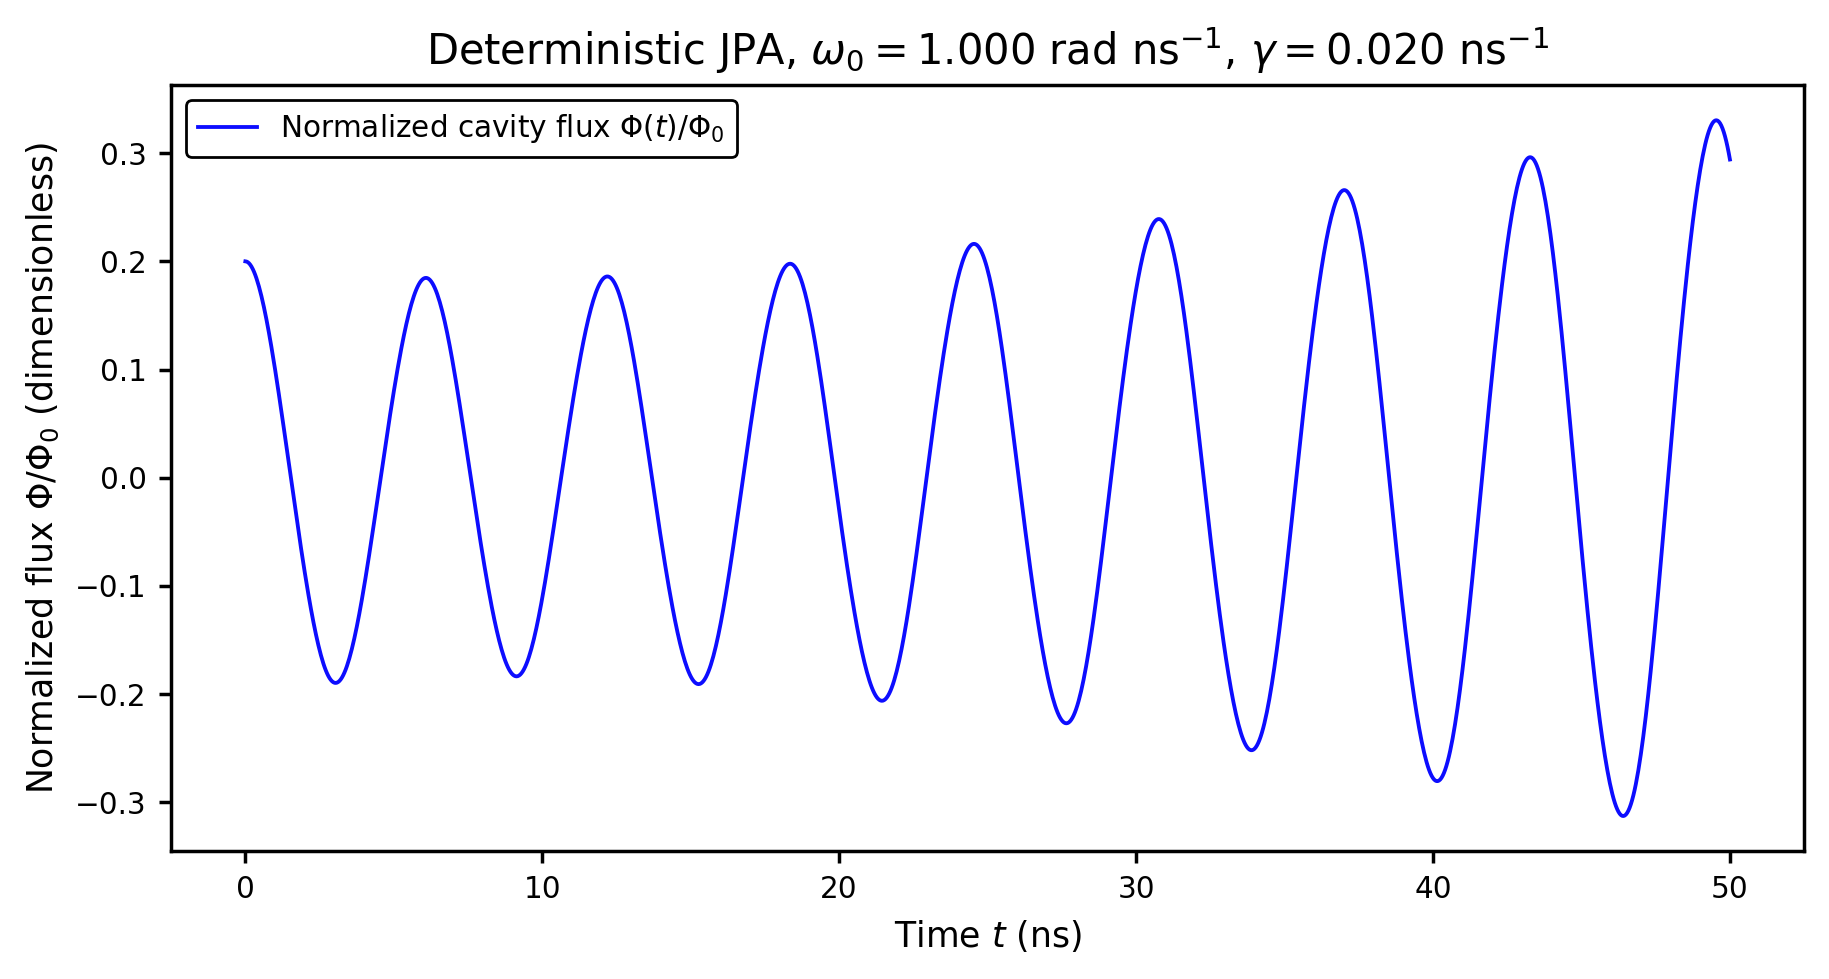

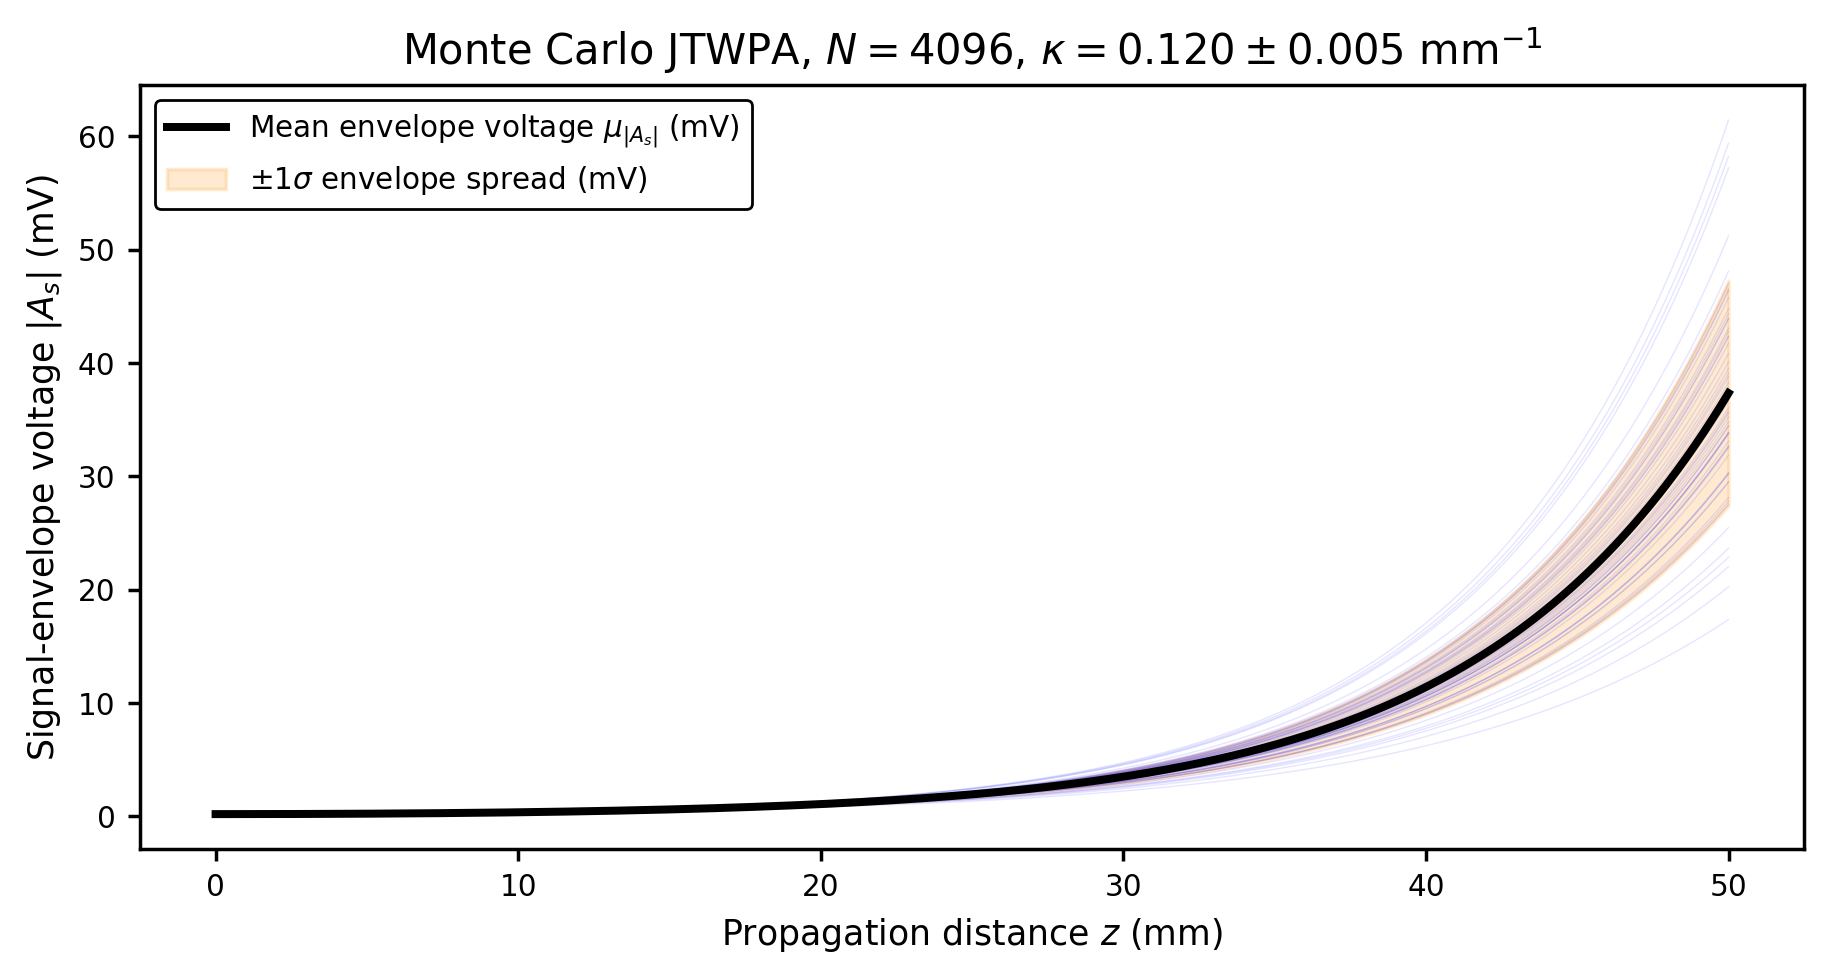

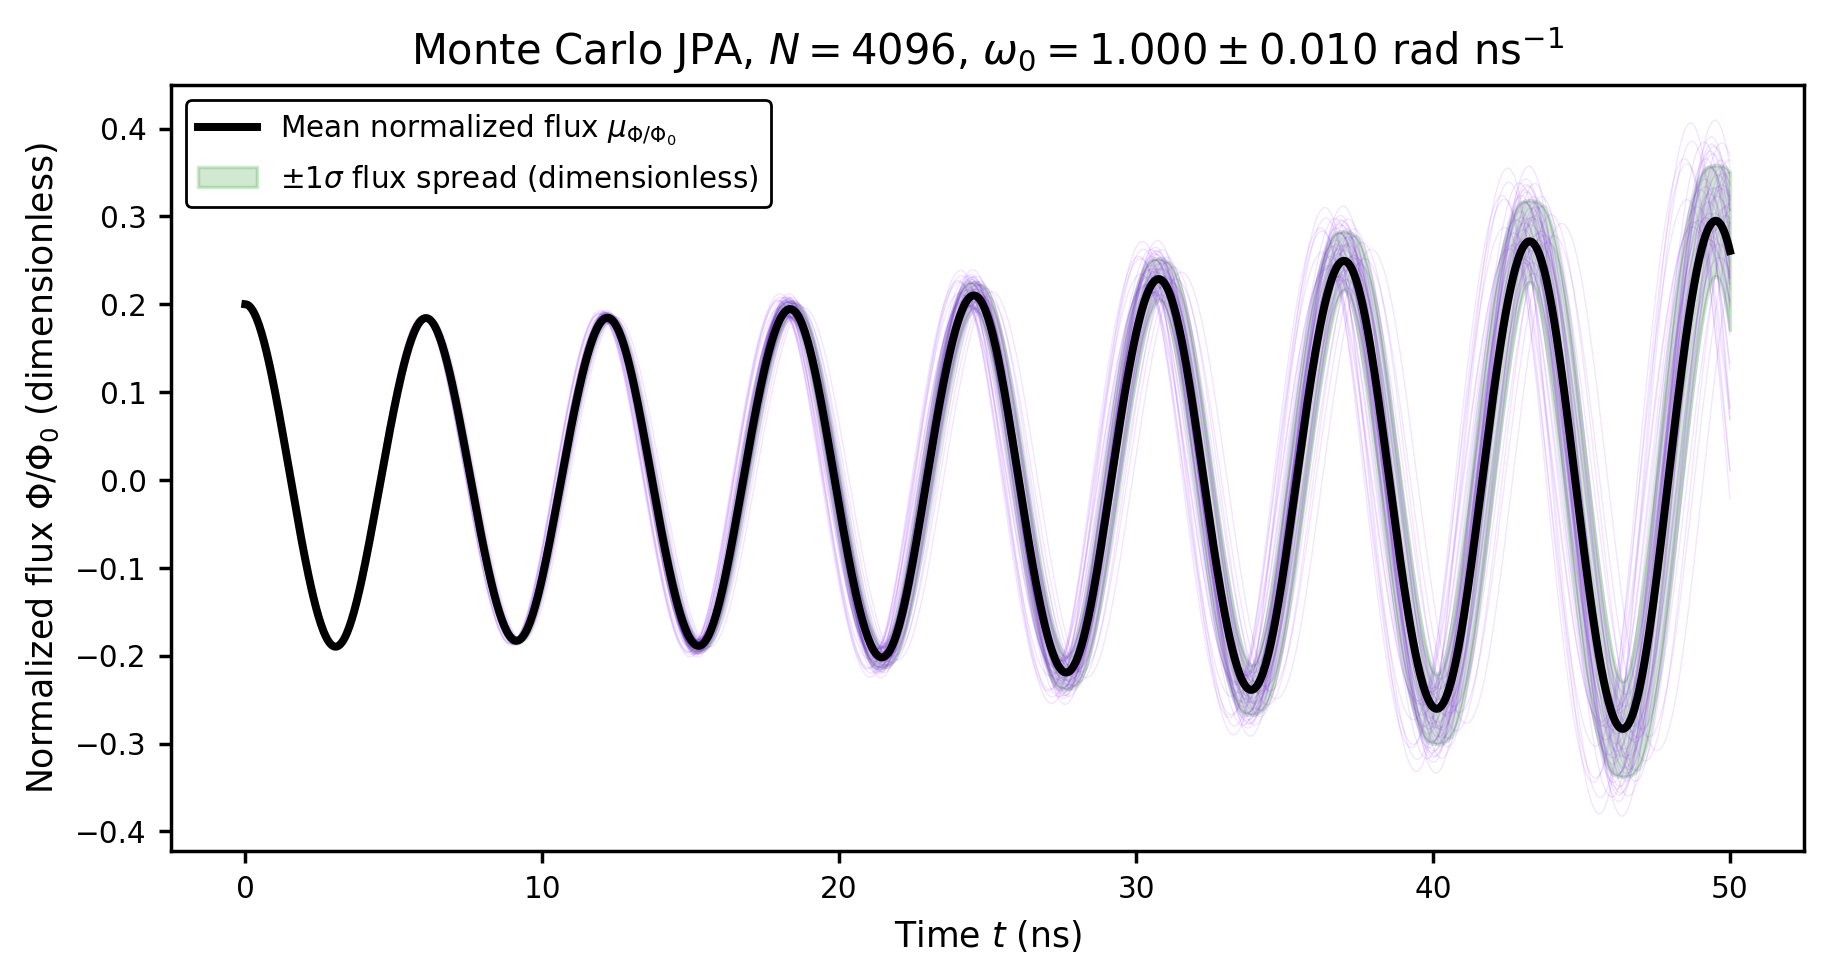

Allocated CUDA memory after simulations: 57.42 MiB


In [21]:
# !python -m pip install -q uv
# !uv pip install -q numpy matplotlib

"""GPU-accelerated Colab plots for parametric-amplifier intuition.

The script renders six plots:
    1. Two illustrative exponentially growing waves.
    2. Four unit-annotated JTWPA/JPA simulation plots.

The final four plots are computed with PyTorch tensors on the selected CUDA
device when REQUIRE_CUDA is True.
"""

from dataclasses import dataclass
from typing import Callable

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch


# =============================================================================
# CONTROL KNOBS WITH UNITS
# =============================================================================

# Runtime controls
REQUIRE_CUDA = True
CUDA_DEVICE_INDEX = 0
RANDOM_SEED = 2026

# Plot controls
MPL_DPI = 250
FIGURE_WIDTH_IN = 7.2
FIGURE_HEIGHT_IN = 3.8
LINE_WIDTH_THIN_PT = 1.1
LINE_WIDTH_THICK_PT = 2.1
TRACE_LINE_WIDTH_PT = 0.40
MEAN_LINE_WIDTH_PT = 2.3
TRACE_ALPHA = 0.10
SPREAD_ALPHA = 0.18
LEGEND_FONT_SIZE_PT = 8.5

# High-contrast color controls. These keep the visual style suitable for
# projectors, screenshots, and white-background reports.
COLOR_WHITE_HEX = "#FFFFFF"
COLOR_BLACK_HEX = "#000000"
COLOR_PURE_BLUE_HEX = "#0000FF"
COLOR_DARK_BLUE_HEX = "#000080"
COLOR_HIGH_CONTRAST_RED_HEX = "#D00000"
COLOR_HIGH_CONTRAST_ORANGE_HEX = "#FF8C00"
COLOR_HIGH_CONTRAST_GREEN_HEX = "#008000"
COLOR_HIGH_CONTRAST_PURPLE_HEX = "#8000FF"
AXIS_SPINE_WIDTH_PT = 1.0
LEGEND_FRAME_LINE_WIDTH_PT = 0.8

# Simple illustrative wave controls
RUN_SIMPLE_REFERENCE_PLOTS = True
SIMPLE_NUM_POINTS = 1_000
SIMPLE_X_MAX_ARBITRARY_UNITS = 40.0
SIMPLE_INITIAL_AMPLITUDE_ARBITRARY_UNITS = 0.2
SIMPLE_ANGULAR_RATE_RAD_PER_ARBITRARY_UNIT = 2.0
SIMPLE_GROWTH_RATES_PER_ARBITRARY_UNIT = (0.10, 0.12)

# Torch integration controls
INTEGRATION_STEPS = 1_200
TORCH_REAL_DTYPE = torch.float32
TORCH_COMPLEX_DTYPE = torch.complex64

# Deterministic JTWPA controls
JTWPA_LENGTH_MM = 50.0
JTWPA_KAPPA_PER_MM = 0.12
JTWPA_DELTA_K_RAD_PER_MM = 0.05
JTWPA_SIGNAL_INIT_MV = 0.2
JTWPA_IDLER_CONJ_INIT_MV = 0.0
JTWPA_CARRIER_WAVE_VECTOR_RAD_PER_MM = 2.0

# Deterministic JPA controls
JPA_DURATION_NS = 50.0
JPA_OMEGA_0_RAD_PER_NS = 1.0
JPA_DAMPING_RATE_PER_NS = 0.02
JPA_MODULATION_DEPTH_DIMENSIONLESS = 0.15
JPA_FLUX_INIT_PHI0 = 0.2
JPA_FLUX_DERIVATIVE_INIT_PHI0_PER_NS = 0.0

# Monte Carlo controls. Increase MONTE_CARLO_SAMPLES on a T4 for smoother bands.
MONTE_CARLO_SAMPLES = 4_096
SUBSET_TRACE_LIMIT = 60

# Monte Carlo JTWPA controls
JTWPA_KAPPA_MEAN_PER_MM = 0.12
JTWPA_KAPPA_STD_PER_MM = 0.005
JTWPA_DELTA_K_MEAN_RAD_PER_MM = 0.05
JTWPA_DELTA_K_STD_RAD_PER_MM = 0.005

# Monte Carlo JPA controls
JPA_OMEGA_0_MEAN_RAD_PER_NS = 1.0
JPA_OMEGA_0_STD_RAD_PER_NS = 0.01
JPA_MODULATION_DEPTH_MEAN_DIMENSIONLESS = 0.15
JPA_MODULATION_DEPTH_STD_DIMENSIONLESS = 0.01


@dataclass(frozen=True)
class JtwpaParameters:
    """Store JTWPA model parameters with explicit units."""

    length_mm: float
    kappa_per_mm: float
    delta_k_rad_per_mm: float
    signal_init_mv: float
    idler_conj_init_mv: float
    carrier_wave_vector_rad_per_mm: float


@dataclass(frozen=True)
class JpaParameters:
    """Store JPA model parameters with explicit units."""

    duration_ns: float
    omega_0_rad_per_ns: float
    damping_rate_per_ns: float
    modulation_depth_dimensionless: float
    flux_init_phi0: float
    flux_derivative_init_phi0_per_ns: float


@dataclass(frozen=True)
class JtwpaMonteCarloParameters:
    """Store JTWPA Monte Carlo distributions with explicit units."""

    length_mm: float
    kappa_mean_per_mm: float
    kappa_std_per_mm: float
    delta_k_mean_rad_per_mm: float
    delta_k_std_rad_per_mm: float
    signal_init_mv: float
    idler_conj_init_mv: float
    carrier_wave_vector_rad_per_mm: float


@dataclass(frozen=True)
class JpaMonteCarloParameters:
    """Store JPA Monte Carlo distributions with explicit units."""

    duration_ns: float
    omega_0_mean_rad_per_ns: float
    omega_0_std_rad_per_ns: float
    damping_rate_per_ns: float
    modulation_depth_mean_dimensionless: float
    modulation_depth_std_dimensionless: float
    flux_init_phi0: float
    flux_derivative_init_phi0_per_ns: float


def configure_matplotlib() -> None:
    """Apply Colab-stable Matplotlib defaults."""

    mpl.rcParams.update(
        {
            "figure.dpi": MPL_DPI,
            "savefig.dpi": MPL_DPI,
            "figure.max_open_warning": 0,
            "font.sans-serif": ["DejaVu Sans", "Arial", "Tahoma"],
            "font.weight": "normal",
            "axes.titleweight": "normal",
            "axes.titlesize": 12,
            "axes.labelsize": 10,
            "legend.fontsize": LEGEND_FONT_SIZE_PT,
            "xtick.labelsize": 8.5,
            "ytick.labelsize": 8.5,
            "figure.facecolor": COLOR_WHITE_HEX,
            "axes.facecolor": COLOR_WHITE_HEX,
            "axes.edgecolor": COLOR_BLACK_HEX,
            "axes.labelcolor": COLOR_BLACK_HEX,
            "axes.titlecolor": COLOR_BLACK_HEX,
            "text.color": COLOR_BLACK_HEX,
            "xtick.color": COLOR_BLACK_HEX,
            "ytick.color": COLOR_BLACK_HEX,
            "legend.edgecolor": COLOR_BLACK_HEX,
            "legend.facecolor": COLOR_WHITE_HEX,
            "legend.framealpha": 1.0,
        }
    )

    try:
        from matplotlib_inline.backend_inline import set_matplotlib_formats

        set_matplotlib_formats("png")
    except ImportError:
        pass


def finalize_figure(figure: mpl.figure.Figure) -> None:
    """Render a static Colab figure and close its handle."""

    figure.canvas.draw_idle()
    plt.show()
    plt.close(figure)


def apply_high_contrast_axis(axis: mpl.axes.Axes) -> None:
    """Apply black axis, tick, label, and legend styling."""

    axis.tick_params(axis="both", colors=COLOR_BLACK_HEX, width=AXIS_SPINE_WIDTH_PT)
    axis.xaxis.label.set_color(COLOR_BLACK_HEX)
    axis.yaxis.label.set_color(COLOR_BLACK_HEX)
    axis.title.set_color(COLOR_BLACK_HEX)

    for spine in axis.spines.values():
        spine.set_color(COLOR_BLACK_HEX)
        spine.set_linewidth(AXIS_SPINE_WIDTH_PT)

    legend = axis.get_legend()
    if legend is None:
        return

    legend.get_frame().set_edgecolor(COLOR_BLACK_HEX)
    legend.get_frame().set_linewidth(LEGEND_FRAME_LINE_WIDTH_PT)
    legend.get_frame().set_facecolor(COLOR_WHITE_HEX)
    for text_item in legend.get_texts():
        text_item.set_color(COLOR_BLACK_HEX)


def get_torch_device() -> torch.device:
    """Return the configured Torch compute device."""

    if torch.cuda.is_available():
        torch.cuda.set_device(CUDA_DEVICE_INDEX)
        return torch.device(f"cuda:{CUDA_DEVICE_INDEX}")

    if REQUIRE_CUDA:
        raise RuntimeError(
            "CUDA is unavailable. In Google Colab, select Runtime, "
            "Change runtime type, and choose a T4 GPU before running again."
        )

    return torch.device("cpu")


def synchronize_device(device: torch.device) -> None:
    """Synchronize CUDA kernels when the active device is CUDA."""

    if device.type == "cuda":
        torch.cuda.synchronize(device)


def configure_torch(device: torch.device) -> None:
    """Configure reproducible Torch execution."""

    torch.manual_seed(RANDOM_SEED)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(RANDOM_SEED)


def print_backend_summary(device: torch.device) -> None:
    """Print device and dtype settings for the GPU-accelerated sections."""

    print(f"PyTorch device: {device}")
    print(f"Real dtype: {TORCH_REAL_DTYPE}")
    print(f"Complex dtype: {TORCH_COMPLEX_DTYPE}")

    if device.type == "cuda":
        print(f"CUDA device name: {torch.cuda.get_device_name(device)}")
        print(
            "Allocated CUDA memory before simulations: "
            f"{torch.cuda.memory_allocated(device) / 1_048_576:.2f} MiB"
        )


def plot_simple_exponential_wave(growth_rate_per_unit: float) -> None:
    """Plot one illustrative exponentially growing sinusoid."""

    x_units = np.linspace(
        0.0,
        SIMPLE_X_MAX_ARBITRARY_UNITS,
        SIMPLE_NUM_POINTS,
    )
    amplitude_units = (
        SIMPLE_INITIAL_AMPLITUDE_ARBITRARY_UNITS
        * np.exp(growth_rate_per_unit * x_units)
    )
    y_units = amplitude_units * np.sin(
        SIMPLE_ANGULAR_RATE_RAD_PER_ARBITRARY_UNIT * x_units
    )

    figure, axis = plt.subplots(
        figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN),
        constrained_layout=True,
    )
    axis.plot(
        x_units,
        y_units,
        color=COLOR_PURE_BLUE_HEX,
        linewidth=LINE_WIDTH_THIN_PT,
    )
    axis.set_xlabel("Propagation coordinate (arbitrary unit)")
    axis.set_ylabel("Wave amplitude (arbitrary unit)")
    axis.set_title(
        "Reference exponentially growing sinusoid, "
        rf"$g={growth_rate_per_unit:.2f}$ arbitrary-unit$^{{-1}}$"
    )
    axis.grid(False)
    apply_high_contrast_axis(axis)
    finalize_figure(figure)


def compute_rk4_step(
    derivative_function: Callable[..., torch.Tensor],
    independent_variable: torch.Tensor,
    state: torch.Tensor,
    step_size: float,
    *args: torch.Tensor | float,
) -> torch.Tensor:
    """Execute one vectorized fourth-order Runge-Kutta step."""

    half_step = 0.5 * step_size
    k1 = derivative_function(independent_variable, state, *args)
    k2 = derivative_function(
        independent_variable + half_step,
        state + half_step * k1,
        *args,
    )
    k3 = derivative_function(
        independent_variable + half_step,
        state + half_step * k2,
        *args,
    )
    k4 = derivative_function(
        independent_variable + step_size,
        state + step_size * k3,
        *args,
    )

    return state + (step_size / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def evaluate_jtwpa_tensor_derivatives(
    position_mm: torch.Tensor,
    state_mv: torch.Tensor,
    kappa_per_mm: torch.Tensor,
    delta_k_rad_per_mm: torch.Tensor,
) -> torch.Tensor:
    """Evaluate JTWPA spatial coupled-mode derivatives over all samples."""

    signal_mv = state_mv[0]
    idler_conj_mv = state_mv[1]
    complex_position_mm = position_mm.to(dtype=state_mv.dtype)
    complex_delta_k = delta_k_rad_per_mm.to(dtype=state_mv.dtype)

    negative_phase = torch.exp(-1j * complex_delta_k * complex_position_mm)
    positive_phase = torch.exp(1j * complex_delta_k * complex_position_mm)

    signal_derivative_mv_per_mm = (
        1j * kappa_per_mm * idler_conj_mv * negative_phase
    )
    idler_conj_derivative_mv_per_mm = (
        -1j * kappa_per_mm * signal_mv * positive_phase
    )

    return torch.stack(
        (signal_derivative_mv_per_mm, idler_conj_derivative_mv_per_mm),
        dim=0,
    )


def integrate_jtwpa_tensor(
    length_mm: float,
    kappa_per_mm: torch.Tensor,
    delta_k_rad_per_mm: torch.Tensor,
    signal_init_mv: float,
    idler_conj_init_mv: float,
    device: torch.device,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Integrate JTWPA equations for one or many samples on Torch tensors."""

    sample_count = int(kappa_per_mm.numel())
    position_mm = torch.linspace(
        0.0,
        length_mm,
        INTEGRATION_STEPS,
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )
    position_step_mm = length_mm / (INTEGRATION_STEPS - 1)

    signal_init = torch.full(
        (sample_count,),
        complex(signal_init_mv, 0.0),
        device=device,
        dtype=TORCH_COMPLEX_DTYPE,
    )
    idler_init = torch.full(
        (sample_count,),
        complex(idler_conj_init_mv, 0.0),
        device=device,
        dtype=TORCH_COMPLEX_DTYPE,
    )
    state_mv = torch.stack((signal_init, idler_init), dim=0)

    signal_history_mv = torch.empty(
        (INTEGRATION_STEPS, sample_count),
        device=device,
        dtype=TORCH_COMPLEX_DTYPE,
    )
    signal_history_mv[0] = state_mv[0]

    with torch.no_grad():
        for step_index in range(INTEGRATION_STEPS - 1):
            state_mv = compute_rk4_step(
                evaluate_jtwpa_tensor_derivatives,
                position_mm[step_index],
                state_mv,
                position_step_mm,
                kappa_per_mm,
                delta_k_rad_per_mm,
            )
            signal_history_mv[step_index + 1] = state_mv[0]

    return position_mm, signal_history_mv


def evaluate_jpa_tensor_derivatives(
    time_ns: torch.Tensor,
    state: torch.Tensor,
    omega_0_rad_per_ns: torch.Tensor,
    damping_rate_per_ns: float,
    modulation_depth_dimensionless: torch.Tensor,
) -> torch.Tensor:
    """Evaluate JPA temporal oscillator derivatives over all samples."""

    flux_phi0 = state[0]
    flux_derivative_phi0_per_ns = state[1]

    modulation = 1.0 + modulation_depth_dimensionless * torch.cos(
        2.0 * omega_0_rad_per_ns * time_ns
    )
    flux_second_derivative_phi0_per_ns2 = (
        -2.0 * damping_rate_per_ns * flux_derivative_phi0_per_ns
        - (omega_0_rad_per_ns**2) * modulation * flux_phi0
    )

    return torch.stack(
        (flux_derivative_phi0_per_ns, flux_second_derivative_phi0_per_ns2),
        dim=0,
    )


def integrate_jpa_tensor(
    duration_ns: float,
    omega_0_rad_per_ns: torch.Tensor,
    damping_rate_per_ns: float,
    modulation_depth_dimensionless: torch.Tensor,
    flux_init_phi0: float,
    flux_derivative_init_phi0_per_ns: float,
    device: torch.device,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Integrate JPA equations for one or many samples on Torch tensors."""

    sample_count = int(omega_0_rad_per_ns.numel())
    time_ns = torch.linspace(
        0.0,
        duration_ns,
        INTEGRATION_STEPS,
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )
    time_step_ns = duration_ns / (INTEGRATION_STEPS - 1)

    flux_init = torch.full(
        (sample_count,),
        flux_init_phi0,
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )
    flux_derivative_init = torch.full(
        (sample_count,),
        flux_derivative_init_phi0_per_ns,
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )
    state = torch.stack((flux_init, flux_derivative_init), dim=0)

    flux_history_phi0 = torch.empty(
        (INTEGRATION_STEPS, sample_count),
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )
    flux_history_phi0[0] = state[0]

    with torch.no_grad():
        for step_index in range(INTEGRATION_STEPS - 1):
            state = compute_rk4_step(
                evaluate_jpa_tensor_derivatives,
                time_ns[step_index],
                state,
                time_step_ns,
                omega_0_rad_per_ns,
                damping_rate_per_ns,
                modulation_depth_dimensionless,
            )
            flux_history_phi0[step_index + 1] = state[0]

    return time_ns, flux_history_phi0


def build_deterministic_jtwpa_outputs(
    params: JtwpaParameters,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute deterministic JTWPA waveform and envelope on the GPU."""

    kappa_per_mm = torch.tensor(
        [params.kappa_per_mm],
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )
    delta_k_rad_per_mm = torch.tensor(
        [params.delta_k_rad_per_mm],
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )

    position_mm, signal_history_mv = integrate_jtwpa_tensor(
        length_mm=params.length_mm,
        kappa_per_mm=kappa_per_mm,
        delta_k_rad_per_mm=delta_k_rad_per_mm,
        signal_init_mv=params.signal_init_mv,
        idler_conj_init_mv=params.idler_conj_init_mv,
        device=device,
    )

    complex_position_mm = position_mm.to(dtype=TORCH_COMPLEX_DTYPE)
    carrier_wave = torch.exp(
        -1j * params.carrier_wave_vector_rad_per_mm * complex_position_mm
    )
    signal_mv = signal_history_mv[:, 0]
    real_waveform_mv = torch.real(signal_mv * carrier_wave)
    envelope_mv = torch.abs(signal_mv)

    synchronize_device(device)

    return (
        position_mm.detach().cpu().numpy(),
        real_waveform_mv.detach().cpu().numpy(),
        envelope_mv.detach().cpu().numpy(),
    )


def build_deterministic_jpa_outputs(
    params: JpaParameters,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute deterministic JPA flux on the GPU."""

    omega_0_rad_per_ns = torch.tensor(
        [params.omega_0_rad_per_ns],
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )
    modulation_depth = torch.tensor(
        [params.modulation_depth_dimensionless],
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )

    time_ns, flux_history_phi0 = integrate_jpa_tensor(
        duration_ns=params.duration_ns,
        omega_0_rad_per_ns=omega_0_rad_per_ns,
        damping_rate_per_ns=params.damping_rate_per_ns,
        modulation_depth_dimensionless=modulation_depth,
        flux_init_phi0=params.flux_init_phi0,
        flux_derivative_init_phi0_per_ns=(
            params.flux_derivative_init_phi0_per_ns
        ),
        device=device,
    )

    synchronize_device(device)

    return (
        time_ns.detach().cpu().numpy(),
        flux_history_phi0[:, 0].detach().cpu().numpy(),
    )


def build_jtwpa_monte_carlo_outputs(
    params: JtwpaMonteCarloParameters,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Compute Monte Carlo JTWPA envelope statistics on the GPU."""

    generator = torch.Generator(device=device.type)
    generator.manual_seed(RANDOM_SEED)

    kappa_samples_per_mm = torch.normal(
        mean=params.kappa_mean_per_mm,
        std=params.kappa_std_per_mm,
        size=(MONTE_CARLO_SAMPLES,),
        generator=generator,
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )
    delta_k_samples_rad_per_mm = torch.normal(
        mean=params.delta_k_mean_rad_per_mm,
        std=params.delta_k_std_rad_per_mm,
        size=(MONTE_CARLO_SAMPLES,),
        generator=generator,
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )

    position_mm, signal_history_mv = integrate_jtwpa_tensor(
        length_mm=params.length_mm,
        kappa_per_mm=kappa_samples_per_mm,
        delta_k_rad_per_mm=delta_k_samples_rad_per_mm,
        signal_init_mv=params.signal_init_mv,
        idler_conj_init_mv=params.idler_conj_init_mv,
        device=device,
    )

    envelope_samples_mv = torch.abs(signal_history_mv)
    mean_envelope_mv = torch.mean(envelope_samples_mv, dim=1)
    std_envelope_mv = torch.std(envelope_samples_mv, dim=1, unbiased=False)

    synchronize_device(device)

    return (
        position_mm.detach().cpu().numpy(),
        envelope_samples_mv.detach().cpu().numpy(),
        mean_envelope_mv.detach().cpu().numpy(),
        std_envelope_mv.detach().cpu().numpy(),
    )


def build_jpa_monte_carlo_outputs(
    params: JpaMonteCarloParameters,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Compute Monte Carlo JPA flux statistics on the GPU."""

    generator = torch.Generator(device=device.type)
    generator.manual_seed(RANDOM_SEED + 1)

    omega_0_samples_rad_per_ns = torch.normal(
        mean=params.omega_0_mean_rad_per_ns,
        std=params.omega_0_std_rad_per_ns,
        size=(MONTE_CARLO_SAMPLES,),
        generator=generator,
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )
    modulation_depth_samples = torch.normal(
        mean=params.modulation_depth_mean_dimensionless,
        std=params.modulation_depth_std_dimensionless,
        size=(MONTE_CARLO_SAMPLES,),
        generator=generator,
        device=device,
        dtype=TORCH_REAL_DTYPE,
    )

    time_ns, flux_samples_phi0 = integrate_jpa_tensor(
        duration_ns=params.duration_ns,
        omega_0_rad_per_ns=omega_0_samples_rad_per_ns,
        damping_rate_per_ns=params.damping_rate_per_ns,
        modulation_depth_dimensionless=modulation_depth_samples,
        flux_init_phi0=params.flux_init_phi0,
        flux_derivative_init_phi0_per_ns=(
            params.flux_derivative_init_phi0_per_ns
        ),
        device=device,
    )

    mean_flux_phi0 = torch.mean(flux_samples_phi0, dim=1)
    std_flux_phi0 = torch.std(flux_samples_phi0, dim=1, unbiased=False)

    synchronize_device(device)

    return (
        time_ns.detach().cpu().numpy(),
        flux_samples_phi0.detach().cpu().numpy(),
        mean_flux_phi0.detach().cpu().numpy(),
        std_flux_phi0.detach().cpu().numpy(),
    )


def plot_deterministic_jtwpa(
    position_mm: np.ndarray,
    real_waveform_mv: np.ndarray,
    envelope_mv: np.ndarray,
    params: JtwpaParameters,
) -> None:
    """Plot deterministic JTWPA output with unit-annotated labels."""

    figure, axis = plt.subplots(
        figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN),
        constrained_layout=True,
    )
    axis.plot(
        position_mm,
        real_waveform_mv,
        color=COLOR_PURE_BLUE_HEX,
        linewidth=LINE_WIDTH_THIN_PT,
        alpha=0.95,
        label=r"Real signal voltage $V_s(z)$ (mV)",
    )
    axis.plot(
        position_mm,
        envelope_mv,
        color=COLOR_BLACK_HEX,
        linewidth=LINE_WIDTH_THICK_PT,
        linestyle="--",
        label=r"Envelope voltage $|A_s(z)|$ (mV)",
    )
    axis.plot(
        position_mm,
        -envelope_mv,
        color=COLOR_HIGH_CONTRAST_RED_HEX,
        linewidth=LINE_WIDTH_THICK_PT,
        linestyle="--",
        alpha=0.90,
        label=r"Negative envelope $-|A_s(z)|$ (mV)",
    )
    axis.set_xlabel(r"Propagation distance $z$ (mm)")
    axis.set_ylabel("Signal voltage amplitude (mV)")
    axis.set_title(
        "Deterministic JTWPA, "
        rf"$\kappa={params.kappa_per_mm:.3f}$ mm$^{{-1}}$, "
        rf"$\Delta k={params.delta_k_rad_per_mm:.3f}$ rad mm$^{{-1}}$"
    )
    axis.legend(loc="upper left")
    axis.grid(False)
    apply_high_contrast_axis(axis)
    finalize_figure(figure)


def plot_deterministic_jpa(
    time_ns: np.ndarray,
    flux_phi0: np.ndarray,
    params: JpaParameters,
) -> None:
    """Plot deterministic JPA output with unit-annotated labels."""

    figure, axis = plt.subplots(
        figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN),
        constrained_layout=True,
    )
    axis.plot(
        time_ns,
        flux_phi0,
        color=COLOR_PURE_BLUE_HEX,
        linewidth=LINE_WIDTH_THIN_PT,
        alpha=0.95,
        label=r"Normalized cavity flux $\Phi(t)/\Phi_0$",
    )
    axis.set_xlabel(r"Time $t$ (ns)")
    axis.set_ylabel(r"Normalized flux $\Phi/\Phi_0$ (dimensionless)")
    axis.set_title(
        "Deterministic JPA, "
        rf"$\omega_0={params.omega_0_rad_per_ns:.3f}$ rad ns$^{{-1}}$, "
        rf"$\gamma={params.damping_rate_per_ns:.3f}$ ns$^{{-1}}$"
    )
    axis.legend(loc="upper left")
    axis.grid(False)
    apply_high_contrast_axis(axis)
    finalize_figure(figure)


def plot_monte_carlo_jtwpa(
    position_mm: np.ndarray,
    envelope_samples_mv: np.ndarray,
    mean_envelope_mv: np.ndarray,
    std_envelope_mv: np.ndarray,
    params: JtwpaMonteCarloParameters,
) -> None:
    """Plot Monte Carlo JTWPA statistics with unit-annotated labels."""

    trace_count = min(SUBSET_TRACE_LIMIT, envelope_samples_mv.shape[1])

    figure, axis = plt.subplots(
        figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN),
        constrained_layout=True,
    )
    axis.plot(
        position_mm,
        envelope_samples_mv[:, :trace_count],
        color=COLOR_PURE_BLUE_HEX,
        linewidth=TRACE_LINE_WIDTH_PT,
        alpha=TRACE_ALPHA,
    )
    axis.plot(
        position_mm,
        mean_envelope_mv,
        color=COLOR_BLACK_HEX,
        linewidth=MEAN_LINE_WIDTH_PT,
        label=r"Mean envelope voltage $\mu_{|A_s|}$ (mV)",
    )
    axis.fill_between(
        position_mm,
        mean_envelope_mv - std_envelope_mv,
        mean_envelope_mv + std_envelope_mv,
        color=COLOR_HIGH_CONTRAST_ORANGE_HEX,
        alpha=SPREAD_ALPHA,
        label=r"$\pm 1\sigma$ envelope spread (mV)",
    )
    axis.set_xlabel(r"Propagation distance $z$ (mm)")
    axis.set_ylabel(r"Signal-envelope voltage $|A_s|$ (mV)")
    axis.set_title(
        "Monte Carlo JTWPA, "
        rf"$N={MONTE_CARLO_SAMPLES}$, "
        rf"$\kappa={params.kappa_mean_per_mm:.3f}"
        rf"\pm{params.kappa_std_per_mm:.3f}$ mm$^{{-1}}$"
    )
    axis.legend(loc="upper left")
    axis.grid(False)
    apply_high_contrast_axis(axis)
    finalize_figure(figure)


def plot_monte_carlo_jpa(
    time_ns: np.ndarray,
    flux_samples_phi0: np.ndarray,
    mean_flux_phi0: np.ndarray,
    std_flux_phi0: np.ndarray,
    params: JpaMonteCarloParameters,
) -> None:
    """Plot Monte Carlo JPA statistics with unit-annotated labels."""

    trace_count = min(SUBSET_TRACE_LIMIT, flux_samples_phi0.shape[1])

    figure, axis = plt.subplots(
        figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN),
        constrained_layout=True,
    )
    axis.plot(
        time_ns,
        flux_samples_phi0[:, :trace_count],
        color=COLOR_HIGH_CONTRAST_PURPLE_HEX,
        linewidth=TRACE_LINE_WIDTH_PT,
        alpha=TRACE_ALPHA,
    )
    axis.plot(
        time_ns,
        mean_flux_phi0,
        color=COLOR_BLACK_HEX,
        linewidth=MEAN_LINE_WIDTH_PT,
        label=r"Mean normalized flux $\mu_{\Phi/\Phi_0}$",
    )
    axis.fill_between(
        time_ns,
        mean_flux_phi0 - std_flux_phi0,
        mean_flux_phi0 + std_flux_phi0,
        color=COLOR_HIGH_CONTRAST_GREEN_HEX,
        alpha=SPREAD_ALPHA,
        label=r"$\pm 1\sigma$ flux spread (dimensionless)",
    )
    axis.set_xlabel(r"Time $t$ (ns)")
    axis.set_ylabel(r"Normalized flux $\Phi/\Phi_0$ (dimensionless)")
    axis.set_title(
        "Monte Carlo JPA, "
        rf"$N={MONTE_CARLO_SAMPLES}$, "
        rf"$\omega_0={params.omega_0_mean_rad_per_ns:.3f}"
        rf"\pm{params.omega_0_std_rad_per_ns:.3f}$ rad ns$^{{-1}}$"
    )
    axis.legend(loc="upper left")
    axis.grid(False)
    apply_high_contrast_axis(axis)
    finalize_figure(figure)


def run_simple_reference_plots() -> None:
    """Render the optional simple reference plots."""

    for growth_rate in SIMPLE_GROWTH_RATES_PER_ARBITRARY_UNIT:
        plot_simple_exponential_wave(growth_rate)


def run_final_four_gpu_plots(device: torch.device) -> None:
    """Compute and render the four unit-annotated GPU simulation plots."""

    jtwpa_params = JtwpaParameters(
        length_mm=JTWPA_LENGTH_MM,
        kappa_per_mm=JTWPA_KAPPA_PER_MM,
        delta_k_rad_per_mm=JTWPA_DELTA_K_RAD_PER_MM,
        signal_init_mv=JTWPA_SIGNAL_INIT_MV,
        idler_conj_init_mv=JTWPA_IDLER_CONJ_INIT_MV,
        carrier_wave_vector_rad_per_mm=JTWPA_CARRIER_WAVE_VECTOR_RAD_PER_MM,
    )
    jpa_params = JpaParameters(
        duration_ns=JPA_DURATION_NS,
        omega_0_rad_per_ns=JPA_OMEGA_0_RAD_PER_NS,
        damping_rate_per_ns=JPA_DAMPING_RATE_PER_NS,
        modulation_depth_dimensionless=JPA_MODULATION_DEPTH_DIMENSIONLESS,
        flux_init_phi0=JPA_FLUX_INIT_PHI0,
        flux_derivative_init_phi0_per_ns=(
            JPA_FLUX_DERIVATIVE_INIT_PHI0_PER_NS
        ),
    )
    jtwpa_monte_carlo_params = JtwpaMonteCarloParameters(
        length_mm=JTWPA_LENGTH_MM,
        kappa_mean_per_mm=JTWPA_KAPPA_MEAN_PER_MM,
        kappa_std_per_mm=JTWPA_KAPPA_STD_PER_MM,
        delta_k_mean_rad_per_mm=JTWPA_DELTA_K_MEAN_RAD_PER_MM,
        delta_k_std_rad_per_mm=JTWPA_DELTA_K_STD_RAD_PER_MM,
        signal_init_mv=JTWPA_SIGNAL_INIT_MV,
        idler_conj_init_mv=JTWPA_IDLER_CONJ_INIT_MV,
        carrier_wave_vector_rad_per_mm=JTWPA_CARRIER_WAVE_VECTOR_RAD_PER_MM,
    )
    jpa_monte_carlo_params = JpaMonteCarloParameters(
        duration_ns=JPA_DURATION_NS,
        omega_0_mean_rad_per_ns=JPA_OMEGA_0_MEAN_RAD_PER_NS,
        omega_0_std_rad_per_ns=JPA_OMEGA_0_STD_RAD_PER_NS,
        damping_rate_per_ns=JPA_DAMPING_RATE_PER_NS,
        modulation_depth_mean_dimensionless=(
            JPA_MODULATION_DEPTH_MEAN_DIMENSIONLESS
        ),
        modulation_depth_std_dimensionless=(
            JPA_MODULATION_DEPTH_STD_DIMENSIONLESS
        ),
        flux_init_phi0=JPA_FLUX_INIT_PHI0,
        flux_derivative_init_phi0_per_ns=(
            JPA_FLUX_DERIVATIVE_INIT_PHI0_PER_NS
        ),
    )

    (
        det_position_mm,
        det_real_waveform_mv,
        det_envelope_mv,
    ) = build_deterministic_jtwpa_outputs(jtwpa_params, device)
    det_time_ns, det_flux_phi0 = build_deterministic_jpa_outputs(
        jpa_params,
        device,
    )
    (
        mc_position_mm,
        envelope_samples_mv,
        mean_envelope_mv,
        std_envelope_mv,
    ) = build_jtwpa_monte_carlo_outputs(jtwpa_monte_carlo_params, device)
    (
        mc_time_ns,
        flux_samples_phi0,
        mean_flux_phi0,
        std_flux_phi0,
    ) = build_jpa_monte_carlo_outputs(jpa_monte_carlo_params, device)

    plot_deterministic_jtwpa(
        det_position_mm,
        det_real_waveform_mv,
        det_envelope_mv,
        jtwpa_params,
    )
    plot_deterministic_jpa(det_time_ns, det_flux_phi0, jpa_params)
    plot_monte_carlo_jtwpa(
        mc_position_mm,
        envelope_samples_mv,
        mean_envelope_mv,
        std_envelope_mv,
        jtwpa_monte_carlo_params,
    )
    plot_monte_carlo_jpa(
        mc_time_ns,
        flux_samples_phi0,
        mean_flux_phi0,
        std_flux_phi0,
        jpa_monte_carlo_params,
    )


def main() -> None:
    """Configure the runtime and render every requested plot."""

    configure_matplotlib()
    device = get_torch_device()
    configure_torch(device)
    print_backend_summary(device)

    if RUN_SIMPLE_REFERENCE_PLOTS:
        run_simple_reference_plots()

    run_final_four_gpu_plots(device)
    synchronize_device(device)

    if device.type == "cuda":
        print(
            "Allocated CUDA memory after simulations: "
            f"{torch.cuda.memory_allocated(device) / 1_048_576:.2f} MiB"
        )


if __name__ == "__main__":
    main()